# Extracting KB

In [27]:
%pip install langchain langgraph langchain-community ollama pydantic scikit-learn pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import json
from typing import TypedDict, Dict, Any
from langgraph.graph import StateGraph, END
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage

## Env variables

In [29]:
# ENV variables
KB_PATH = "./input/KB.md"
PROMPTS_PATH = "./prompts/prompts.json"
ollama_model = "llama3.2"
ollama_model_temperature = 0

## Langgraph setup

In [ ]:
#Laggraph setup

#state
class KBState(TypedDict):
    kb_text: str
    prompts: Dict[str, Any]
    outputs: Dict[str, Any]
    prompts_used: Dict[str, Any]

#llm
llm = ChatOllama(
    model=ollama_model,
    temperature=ollama_model_temperature,
    format="json",
)

#helper functions
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(path: str, data: Dict):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

def run_llm(system_prompt: str, user_prompt: str):
    res = llm.invoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt),
        ]
    )
    
    return json.loads(res.content)

# Node — Load KB + prompts.json
def load_inputs(state: KBState):
    state["kb_text"] = open(KB_PATH, "r", encoding="utf-8").read()
    state["prompts"] = load_json(PROMPTS_PATH)
    state["outputs"] = {}
    state["prompts_used"] = {}
    return state

def run_extraction(key: str):
    def node(state: KBState):
        prompt_block = state["prompts"][key]

        system_prompt = prompt_block["system"]
        user_template = prompt_block["user"]

        user_prompt = user_template.replace("{kb}", state["kb_text"])
        
        # Special handling for feature_goal: extract and pass feature columns
        if key == "feature_goal":
            segmented_csv_path = "./output/users_segmented.csv"
            df_segmented = pd.read_csv(segmented_csv_path)
            
            # Exclude metadata and segment columns
            exclude_cols = {'user_id', 'segment_id', 'segment_name', 'lifecycle_stage', 'activation_level', 'dominant_propensity'}
            feature_columns = [col for col in df_segmented.columns if col not in exclude_cols]
            
            # Format features as a numbered list for clarity
            features_str = "\n".join([f"{i+1}. {col}" for i, col in enumerate(feature_columns)])
            user_prompt = user_prompt.replace("{features}", features_str)

        result = run_llm(system_prompt, user_prompt)

        state["outputs"][key] = result
        state["prompts_used"][key] = {
            "system": system_prompt,
            "user": user_prompt,
        }
        return state

    return node

def save_outputs(state: KBState):
    # save each extraction separately
    for key, value in state["outputs"].items():
        save_json(f"./output/{key}.json", value)

    return state


builder = StateGraph(KBState)

builder.add_node("load", load_inputs)

# load prompts to know keys
prompt_keys = load_json(PROMPTS_PATH).keys()

previous = "load"

for key in prompt_keys:
    node_name = f"extract_{key}"
    builder.add_node(node_name, run_extraction(key))
    builder.add_edge(previous, node_name)
    previous = node_name

builder.add_node("save", save_outputs)
builder.add_edge(previous, "save")
builder.add_edge("save", END)

builder.set_entry_point("load")

graph = builder.compile()

## Execution cell

In [31]:

# -------------------------------------------------
# Run
# -------------------------------------------------
initial_state: KBState = {
    "kb_text": "",
    "prompts": {},
    "outputs": {},
    "prompts_used": {},
}

graph.invoke(initial_state);

ConnectTimeout: HTTPConnectionPool(host='172.30.17.39', port=11434): Max retries exceeded with url: /api/chat (Caused by ConnectTimeoutError(<HTTPConnection(host='172.30.17.39', port=11434) at 0x2281970d0a0>, 'Connection to 172.30.17.39 timed out. (connect timeout=None)'))

# Missing data handeling 

In [31]:
%pip install pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [33]:
# ENV variables
users_csv_path = "./input/users.csv"

## Encode the string columns

In [34]:
# helper
def label_encode_sorted(df: pd.DataFrame, column: str) -> pd.DataFrame:
   
    if column not in df.columns:
        raise ValueError(f"{column} not in dataframe")

    new_df = df.copy()

    # build mapping from non-null values only
    non_null = new_df[column].dropna().astype(str)
    uniques = sorted(non_null.unique())
    mapping = {v: i for i, v in enumerate(uniques)}

    # Convert column to object dtype first to handle assignment
    new_df[column] = new_df[column].astype('object')
    
    # map only non-null
    new_df.loc[new_df[column].notna(), column] = (
        new_df.loc[new_df[column].notna(), column]
        .astype(str)
        .map(mapping)
    )
    
    # Convert to int64
    new_df[column] = new_df[column].astype('Int64')

    return new_df

## string columns to encode

In [35]:
# specify columns to encode
columns_to_encode = [
    "lifecycle_stage",
    "age_band",
    "region",
    "feature_ai_tutor_used",
    "feature_leaderboard_viewed",
    "feature_progress_checked",
]

## Later handle the iterative imputer failure

In [36]:
df = pd.read_csv(users_csv_path)
df_encoding = df.copy()

for column in columns_to_encode:
    if column not in df.columns:
        raise ValueError(f"{column} not in dataframe")
    else:
        # Convert boolean columns to string before encoding
        if df_encoding[column].dtype == 'bool':
            df_encoding[column] = df_encoding[column].astype(str).str.replace('True', 'true').str.replace('False', 'false')
        df_encoding = label_encode_sorted(df_encoding, column)

df_encoding.to_csv("./output/users_encoded.csv", index=False)

In [37]:
# later cange this to users_encoded.csv
encoded_user_csv_path = "./input/users.csv"

In [38]:
df = pd.read_csv(encoded_user_csv_path)

numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df.to_csv("./output/users_imputed.csv", index=False)

# Generating Propensity and Activeness scores

In [39]:
df = pd.read_csv("./output/users_imputed.csv")

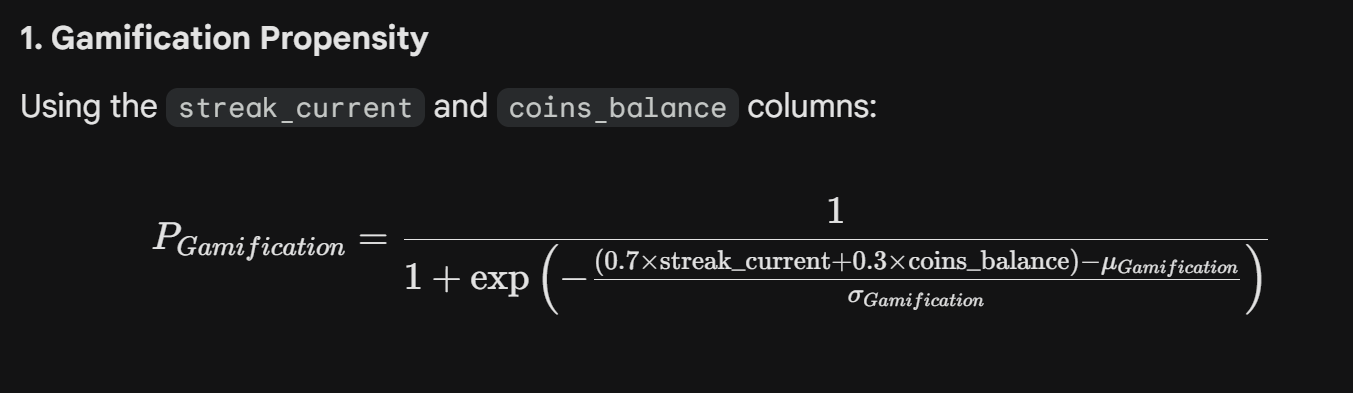

In [40]:
gamification_score = 0.7 * df['streak_current'] + 0.3 * df['coins_balance']
mu = gamification_score.mean()
sigma = gamification_score.std()
df['gamification_propensity'] = 1 / (1 + np.exp(-(gamification_score - mu) / sigma))
df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197


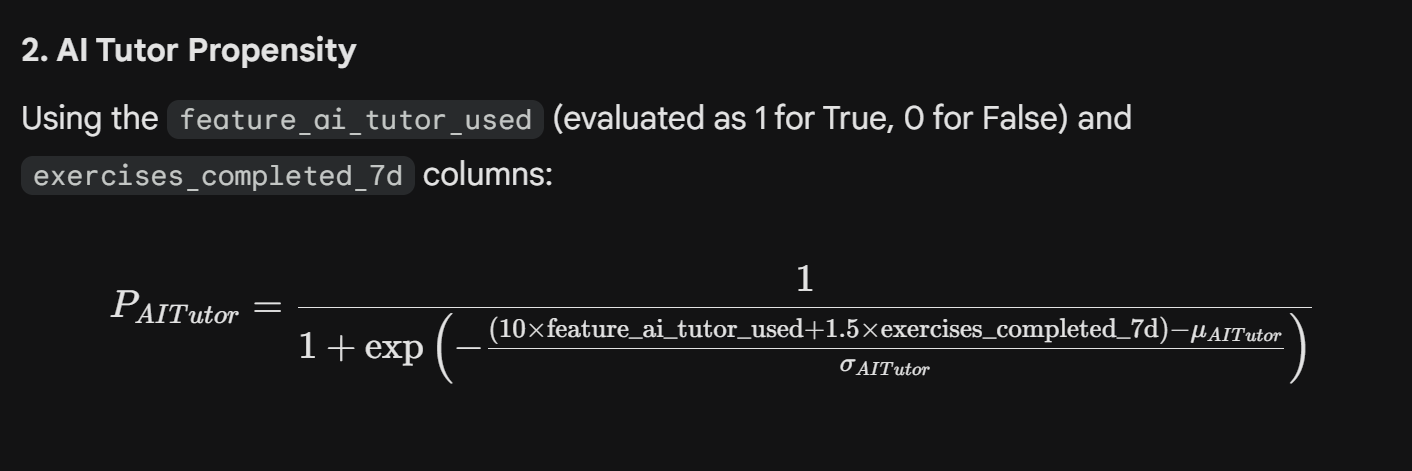

In [41]:
ai_tutor_score = 10 * df['feature_ai_tutor_used'] + 1.5 * df['exercises_completed_7d']
mu = ai_tutor_score.mean()
sigma = ai_tutor_score.std()
df['ai_tutor_propensity'] = 1 / (1 + np.exp(-(ai_tutor_score - mu) / sigma))
df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity,ai_tutor_propensity
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197,0.736033


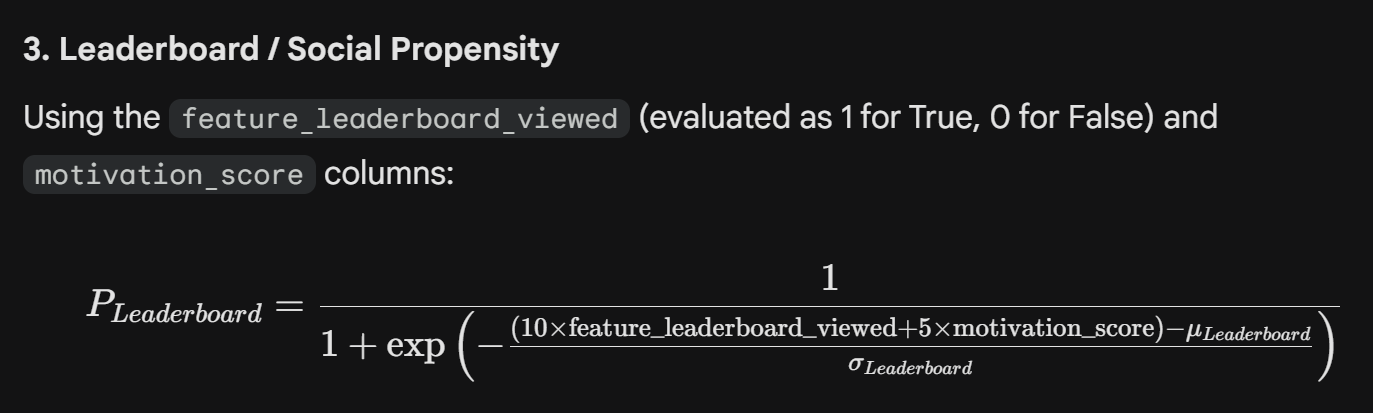

In [42]:
leaderboard_score = 10 * df['feature_leaderboard_viewed'] + 5 * df['motivation_score']
mu = leaderboard_score.mean()
sigma = leaderboard_score.std()
df['leaderboard_propensity'] = 1 / (1 + np.exp(-(leaderboard_score - mu) / sigma))

df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity,ai_tutor_propensity,leaderboard_propensity
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197,0.736033,0.269036


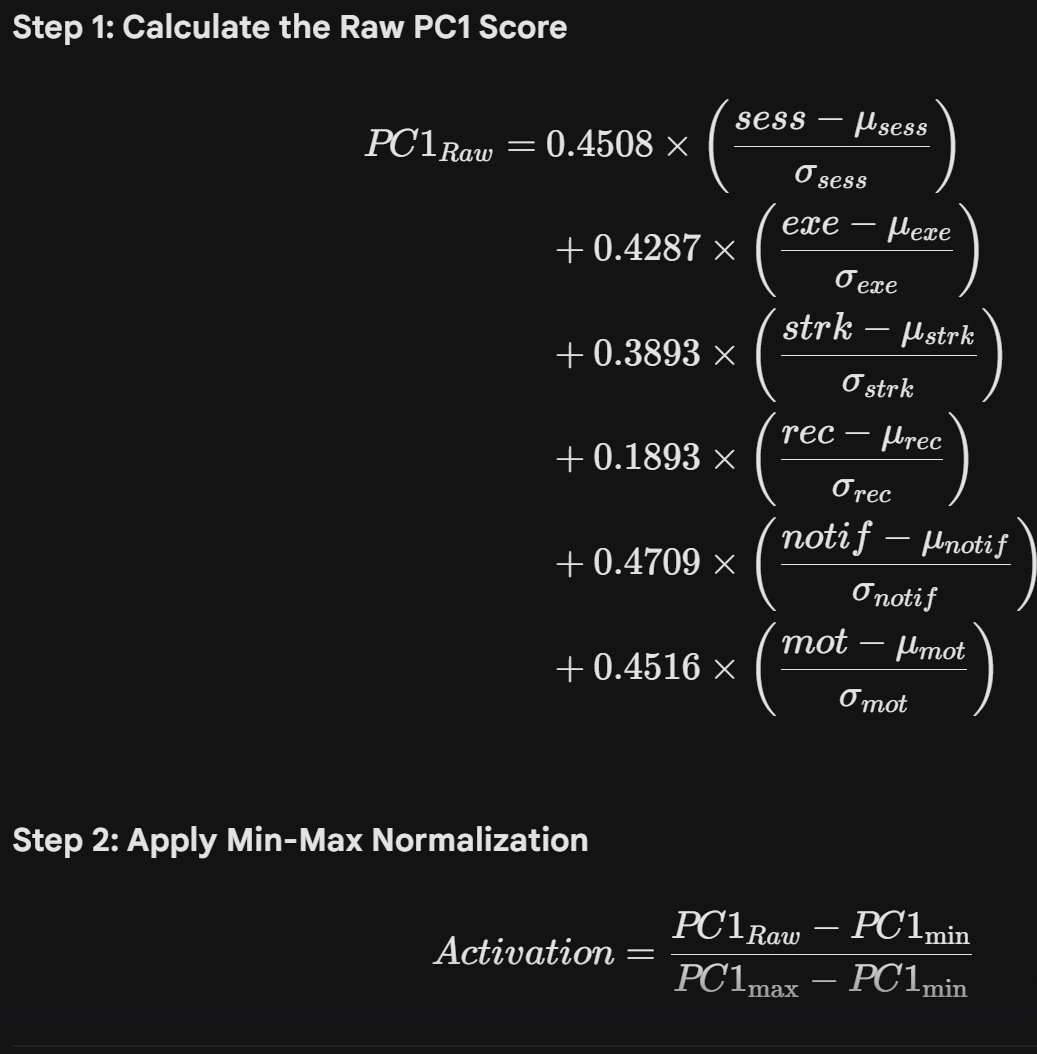

In [43]:
from sklearn.decomposition import PCA

cols = ['sessions_last_7d', 'exercises_completed_7d', 'streak_current', 'notif_open_rate_30d', 'motivation_score']
standardized = pd.DataFrame()
for col in cols:
    standardized[col] = (df[col] - df[col].mean()) / df[col].std()

pca = PCA(n_components=1)
pca.fit(standardized)
weights = {col: pca.components_[0][i] for i, col in enumerate(cols)}

pc1_raw = sum(weights[col] * standardized[col] for col in cols)
pc1_min = pc1_raw.min()
pc1_max = pc1_raw.max()
df['activation_score'] = (pc1_raw - pc1_min) / (pc1_max - pc1_min)

df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity,ai_tutor_propensity,leaderboard_propensity,activation_score
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197,0.736033,0.269036,0.676695


In [44]:
df.to_csv("./output/users_propensity_generated.csv", index=False)

# Segmenting users 

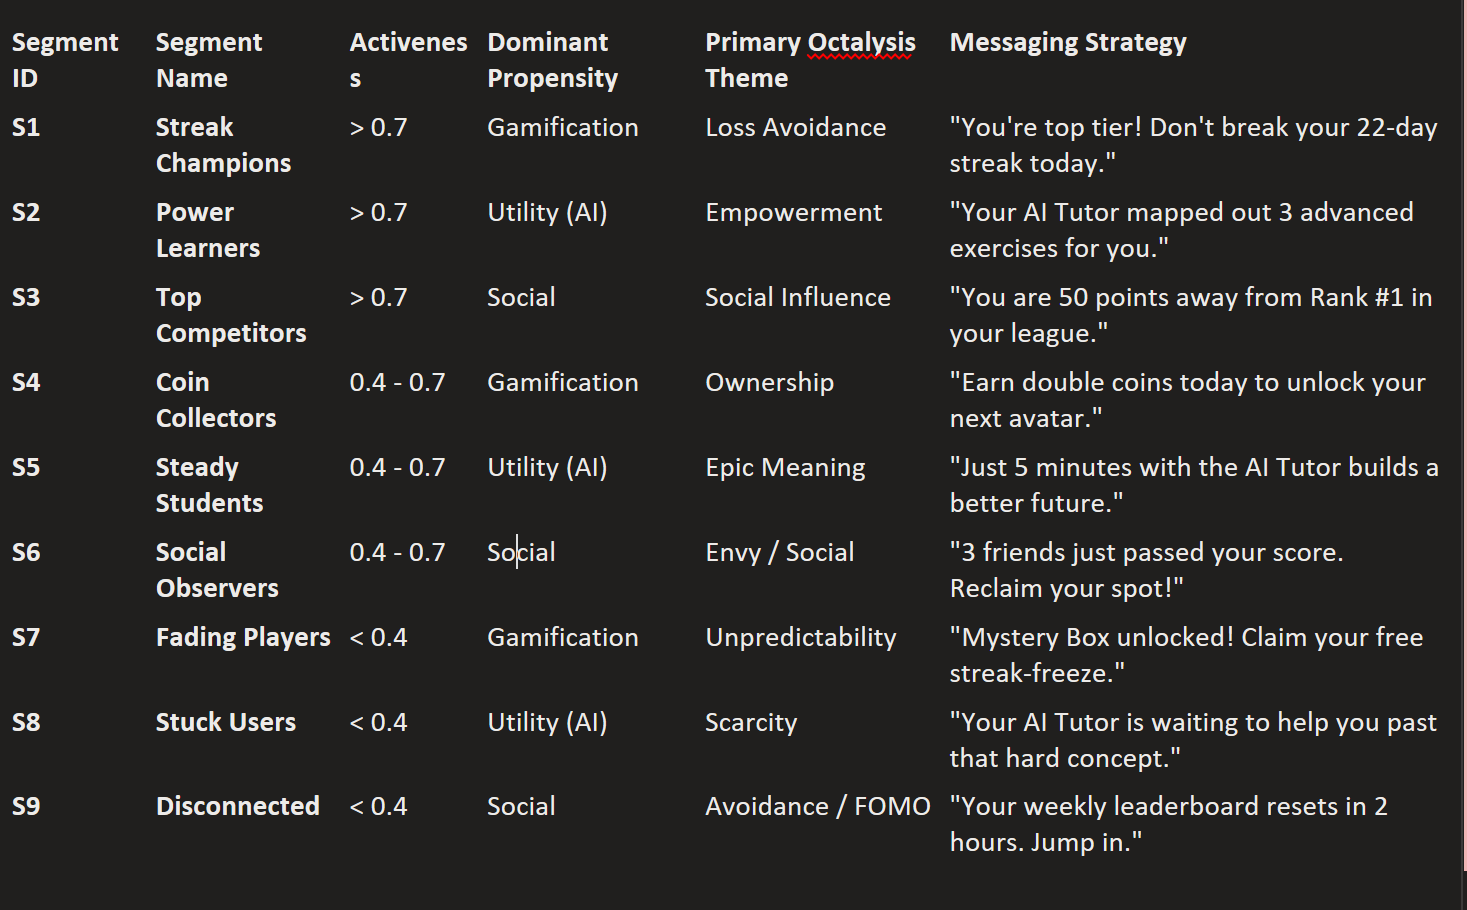

In [51]:
df = pd.read_csv("./output/users_propensity_generated.csv")

df['dominant_propensity'] = df[['gamification_propensity', 'ai_tutor_propensity', 'leaderboard_propensity']].idxmax(axis=1)
df['dominant_propensity'] = df['dominant_propensity'].str.replace('_propensity', '')

def get_activation_level(score):
    if score > 0.7:
        return 'High'
    elif score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

df['activation_level'] = df['activation_score'].apply(get_activation_level)

segment_map = {
    ('gamification', 'High'): ('S1', 'Streak Champions'),
    ('ai_tutor', 'High'): ('S2', 'Power Learners'),
    ('leaderboard', 'High'): ('S3', 'Top Competitors'),
    ('gamification', 'Medium'): ('S4', 'Coin Collectors'),
    ('ai_tutor', 'Medium'): ('S5', 'Steady Students'),
    ('leaderboard', 'Medium'): ('S6', 'Social Observers'),
    ('gamification', 'Low'): ('S7', 'Fading Players'),
    ('ai_tutor', 'Low'): ('S8', 'Stuck Users'),
    ('leaderboard', 'Low'): ('S9', 'Disconnected'),
}

df[['segment_id', 'segment_name']] = df.apply(
    lambda row: pd.Series(segment_map[(row['dominant_propensity'], row['activation_level'])]),
    axis=1
)

df.to_csv("./output/users_segmented.csv", index=False)

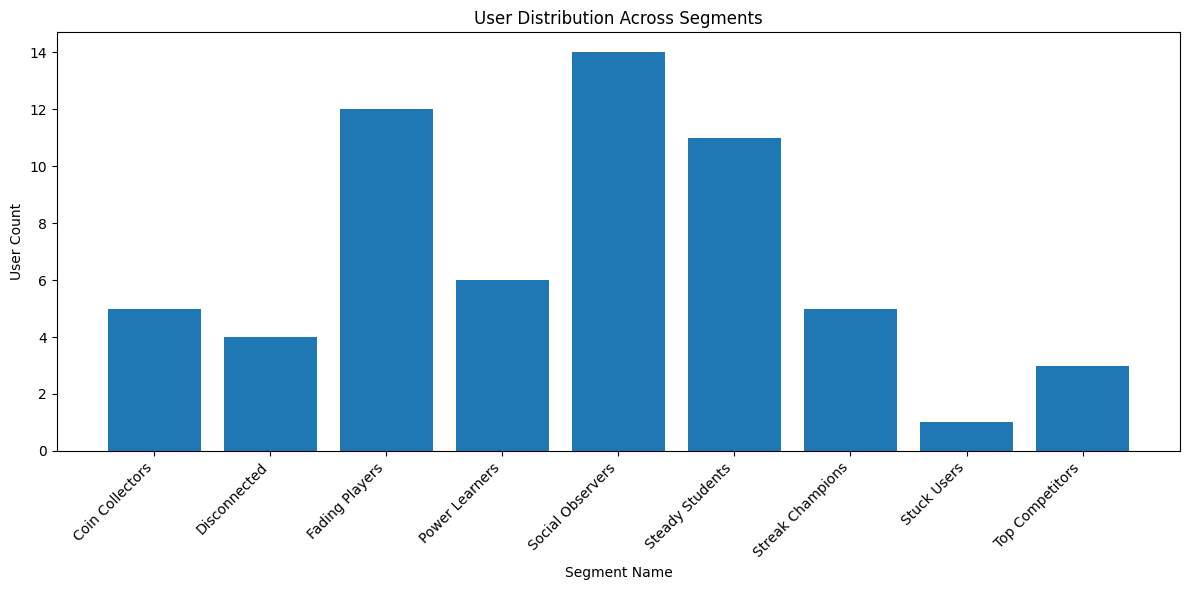

In [52]:
segment_counts = df['segment_name'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel('Segment Name')
plt.ylabel('User Count')
plt.title('User Distribution Across Segments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### computing segments though GMM 
 GMM Block dropped will not use this

In [53]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("./output/users_propensity_generated.csv")

features = df[['gamification_propensity', 'ai_tutor_propensity', 'leaderboard_propensity', 'activation_score']].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

bic_scores = []
n_components_range = range(6, 13)

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(features_scaled)
    bic_scores.append(gmm.bic(features_scaled))

optimal_n = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of segments: {optimal_n}")
print(f"Minimum BIC: {min(bic_scores):.4f}")

gmm_optimal = GaussianMixture(n_components=optimal_n, random_state=42)
df['gmm_segment'] = gmm_optimal.fit_predict(features_scaled)

df.to_csv("./output/users_segmented_GMM.csv", index=False)
print(f"Segmentation complete. {optimal_n} segments generated.")

Optimal number of segments: 12
Minimum BIC: 277.7602
Segmentation complete. 12 segments generated.


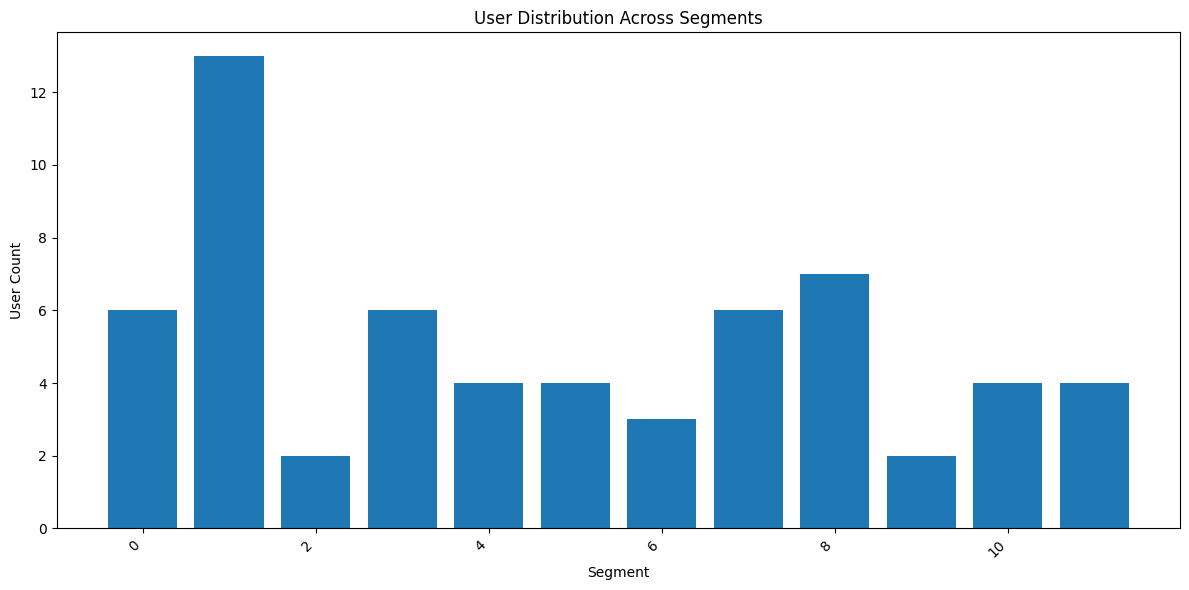

In [54]:
segment_counts = df['gmm_segment'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel('Segment')
plt.ylabel('User Count')
plt.title('User Distribution Across Segments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
segment_summary = df.groupby('gmm_segment')[['gamification_propensity', 'ai_tutor_propensity', 'leaderboard_propensity', 'activation_score']].agg(['mean', 'std', 'min', 'max'])

print(segment_summary)

segment_counts = df['gmm_segment'].value_counts().sort_index()
print("\nSegment Sizes:")
print(segment_counts)

for segment in range(optimal_n):
    segment_data = df[df['gmm_segment'] == segment]
    print(f"\n--- Segment {segment} ---")
    print(f"User Count: {len(segment_data)}")
    print(f"Avg Gamification Propensity: {segment_data['gamification_propensity'].mean():.4f}")
    print(f"Avg AI Tutor Propensity: {segment_data['ai_tutor_propensity'].mean():.4f}")
    print(f"Avg Leaderboard Propensity: {segment_data['leaderboard_propensity'].mean():.4f}")
    print(f"Avg Activation Score: {segment_data['activation_score'].mean():.4f}")
    print(f"Dominant Feature: {segment_data[['gamification_propensity', 'ai_tutor_propensity', 'leaderboard_propensity']].mean().idxmax().replace('_propensity', '')}")

            gamification_propensity                                \
                               mean       std       min       max   
gmm_segment                                                         
0                          0.339398  0.032270  0.281426  0.372711   
1                          0.272200  0.009894  0.258635  0.291559   
2                          0.809438  0.050570  0.773680  0.845197   
3                          0.667237  0.077248  0.549169  0.757540   
4                          0.291413  0.007618  0.285154  0.301130   
5                          0.428162  0.052442  0.351092  0.461730   
6                          0.355665  0.102301  0.289289  0.473477   
7                          0.726146  0.048220  0.677974  0.779099   
8                          0.845794  0.048739  0.784113  0.891746   
9                          0.645346  0.043303  0.614726  0.675966   
10                         0.495049  0.003121  0.491951  0.498377   
11                         0.31657

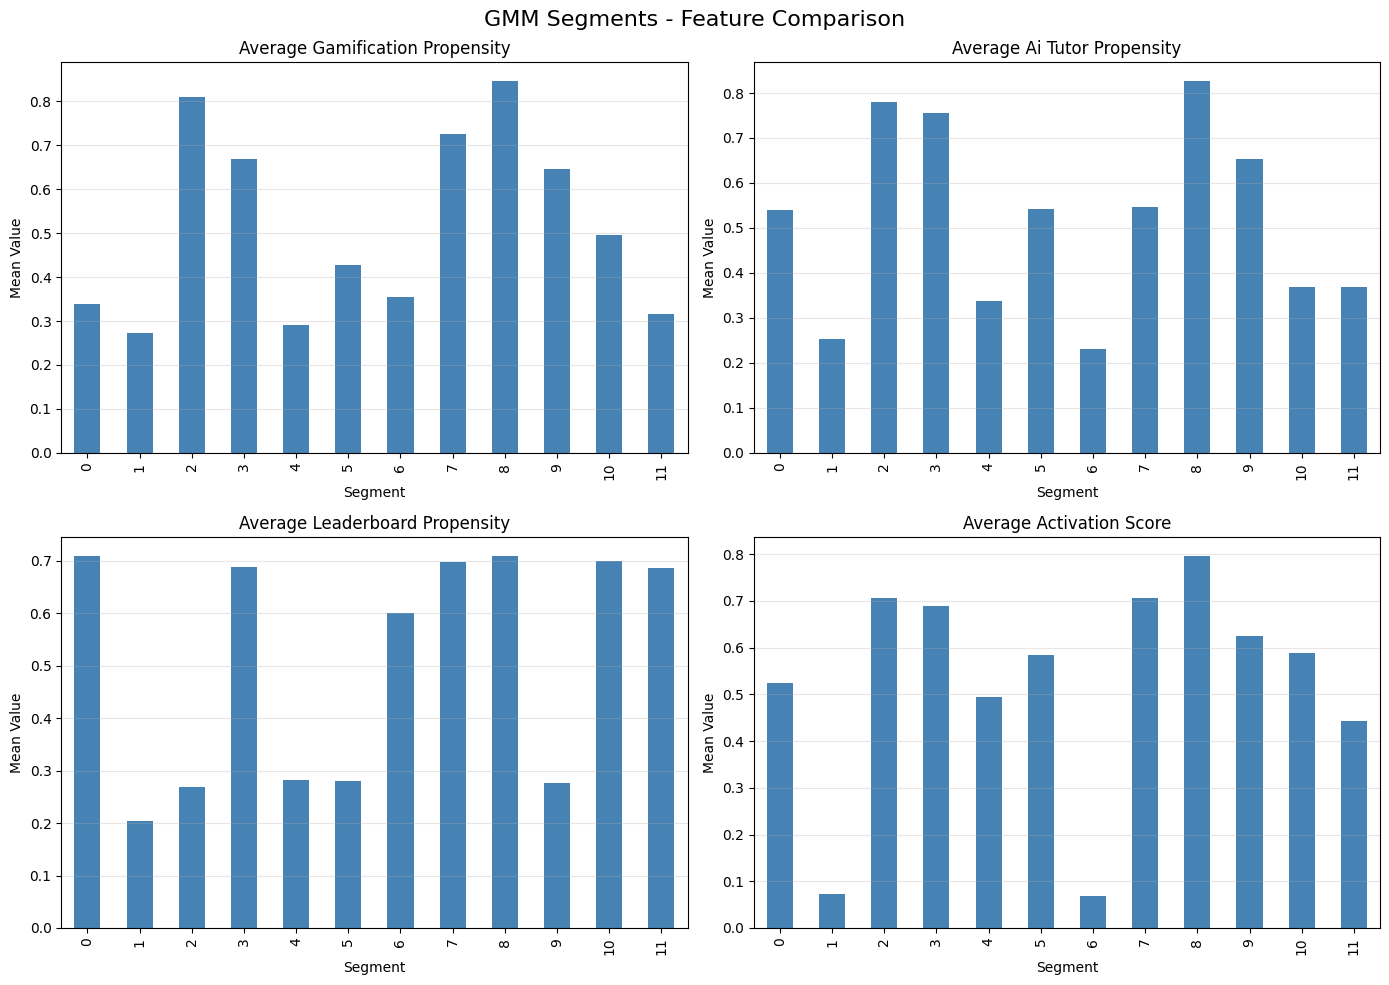

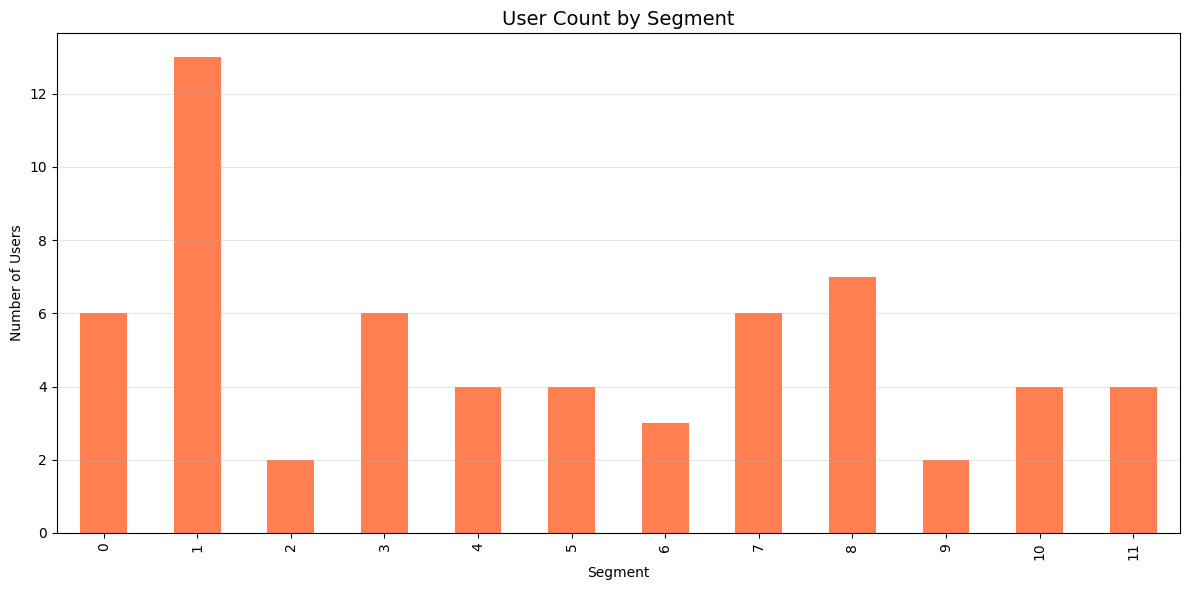

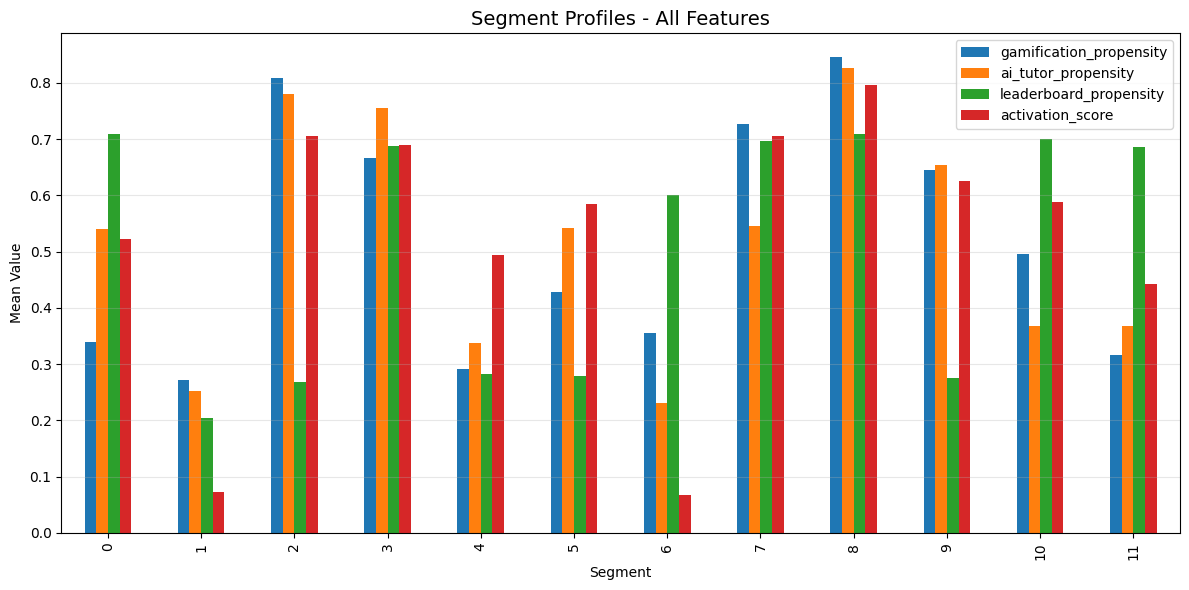

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GMM Segments - Feature Comparison', fontsize=16)

features = ['gamification_propensity', 'ai_tutor_propensity', 'leaderboard_propensity', 'activation_score']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    segment_means = df.groupby('gmm_segment')[feature].mean()
    segment_means.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Average {feature.replace("_", " ").title()}', fontsize=12)
    ax.set_xlabel('Segment')
    ax.set_ylabel('Mean Value')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
segment_counts = df['gmm_segment'].value_counts().sort_index()
segment_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('User Count by Segment', fontsize=14)
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Users')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

segment_profiles = df.groupby('gmm_segment')[features].mean()
fig, ax = plt.subplots(figsize=(12, 6))
segment_profiles.plot(kind='bar', ax=ax)
ax.set_title('Segment Profiles - All Features', fontsize=14)
ax.set_xlabel('Segment')
ax.set_ylabel('Mean Value')
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Assigning Goals , Sub-Goals for ech segment * lifecycle stage

In [58]:
# Generate Segment × Lifecycle Stage Goals (36 Combinations)

# Load feature goals and user segments
df_segments = pd.read_csv("./output/users_segmented.csv")
feature_goals = load_json("./output/feature_goal.json")

# Map lifecycle stages to contextual modifiers
lifecycle_context = {
    "trial": {
        "description": "Early Stage - Building Habits",
        "goal_modifier": "rapid adoption & habit formation",
        "focus": "Quick wins and onboarding",
    },
    "paid": {
        "description": "Engaged - Maximizing Value",
        "goal_modifier": "deepening engagement & retention",
        "focus": "Sustained usage and progression",
    },
    "churned": {
        "description": "At-Risk - Re-activation Needed",
        "goal_modifier": "re-engagement & recovering lost habits",
        "focus": "Breaking inactivity cycle",
    },
    "inactive": {
        "description": "Dormant - Win-Back Campaign",
        "goal_modifier": "compelling return value proposition",
        "focus": "Removing friction to return",
    },
}

# Build feature goal mapping by propensity type
feature_goal_map = {}
for feature in feature_goals["features"]:
    propensity_type = feature["feature_name"].replace("_propensity", "")
    feature_goal_map[propensity_type] = {
        "primary_goal": feature["primary_goal"],
        "sub_goals": feature["sub_goals"],
        "progression_goals": feature["day_on_day_progression_goals"],
    }

# Get unique segment and lifecycle combinations
segments = sorted(df_segments[['segment_id', 'segment_name', 'dominant_propensity', 'activation_level']].drop_duplicates()['segment_id'].tolist())
lifecycle_stages = sorted(df_segments['lifecycle_stage'].unique().tolist())

# Ensure exactly 4 lifecycle stages (trial, paid, churned, inactive)
expected_stages = ["trial", "paid", "churned", "inactive"]
available_stages = [s for s in expected_stages if s in lifecycle_stages]
if len(available_stages) < 4:
    available_stages = lifecycle_stages + [s for s in expected_stages if s not in lifecycle_stages]
available_stages = available_stages[:4]

print(f"Segments: {segments}")
print(f"Lifecycle Stages: {available_stages}")
print(f"Total Combinations: {len(segments)} segments × {len(available_stages)} stages = {len(segments) * len(available_stages)}")

# Generate 36 combinations
segment_lifecycle_goals = {
    "combinations": [],
    "metadata": {
        "total_segments": len(segments),
        "total_lifecycle_stages": len(available_stages),
        "total_combinations": len(segments) * len(available_stages),
        "generated_at": pd.Timestamp.now().isoformat(),
    }
}

for segment_id in segments:
    segment_info = df_segments[df_segments['segment_id'] == segment_id].iloc[0]
    segment_name = segment_info['segment_name']
    dominant_propensity = segment_info['dominant_propensity']
    activation_level = segment_info['activation_level']
    
    # Get base goals from feature_goal.json using dominant propensity
    base_goals = feature_goal_map.get(dominant_propensity, {})
    
    for lifecycle_stage in available_stages:
        lifecycle_info = lifecycle_context.get(lifecycle_stage, {})
        
        # Customize goals based on segment + lifecycle stage
        combination = {
            "combination_id": f"{segment_id}_{lifecycle_stage}",
            "segment_id": segment_id,
            "segment_name": segment_name,
            "lifecycle_stage": lifecycle_stage,
            "lifecycle_description": lifecycle_info.get("description", ""),
            "dominant_propensity": dominant_propensity,
            "activation_level": activation_level,
            "primary_goal": f"{base_goals.get('primary_goal', 'Engagement')} • {lifecycle_info.get('goal_modifier', 'optimize engagement')}",
            "sub_goals": [
                f"{sub_goal} ({lifecycle_stage.title()} context: {lifecycle_info.get('focus', 'engagement')})"
                for sub_goal in base_goals.get('sub_goals', [])
            ],
            "day_on_day_progression_goals": [
                f"{prog_goal} • Track in {lifecycle_stage} phase"
                for prog_goal in base_goals.get('progression_goals', [])
            ],
            "lifecycle_context": {
                "stage": lifecycle_stage,
                "description": lifecycle_info.get("description", ""),
                "focus": lifecycle_info.get("focus", ""),
                "goal_modifier": lifecycle_info.get("goal_modifier", ""),
            }
        }
        segment_lifecycle_goals["combinations"].append(combination)

# Save to output
save_json("./output/segment_lifecycle_goals.json", segment_lifecycle_goals)

print(f"\n✓ Generated {len(segment_lifecycle_goals['combinations'])} segment × lifecycle stage goal combinations")
print(f"✓ Saved to: ./output/segment_lifecycle_goals.json")
print("\nSample combination (S1_trial):")
sample = next((c for c in segment_lifecycle_goals["combinations"] if c["combination_id"] == "S1_trial"), None)
if sample:
    print(json.dumps(sample, indent=2))

Segments: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Lifecycle Stages: ['trial', 'paid', 'churned', 'inactive']
Total Combinations: 9 segments × 4 stages = 36

✓ Generated 36 segment × lifecycle stage goal combinations
✓ Saved to: ./output/segment_lifecycle_goals.json

Sample combination (S1_trial):
{
  "combination_id": "S1_trial",
  "segment_id": "S1",
  "segment_name": "Streak Champions",
  "lifecycle_stage": "trial",
  "lifecycle_description": "Early Stage - Building Habits",
  "dominant_propensity": "gamification",
  "activation_level": "High",
  "primary_goal": "Motivation \u2192 session frequency \u2022 rapid adoption & habit formation",
  "sub_goals": [
    "Streaks (Trial context: Quick wins and onboarding)",
    "XP & levels (Trial context: Quick wins and onboarding)",
    "Leaderboards (Trial context: Quick wins and onboarding)"
  ],
  "day_on_day_progression_goals": [
    "Daily speaking sessions \u2022 Track in trial phase",
    "Streak length \u2022 Track in t

In [59]:
## Build segment profiles from users_segmented.csv

def build_segment_profiles():
    """Build aggregated segment profiles from individual user data."""
    df = pd.read_csv("./output/users_segmented.csv")
    
    segment_profiles = {}
    
    for segment_id in df['segment_id'].unique():
        segment_data = df[df['segment_id'] == segment_id]
        segment_names = segment_data['segment_name'].unique()
        
        if len(segment_names) > 0:
            segment_name = segment_names[0]
            dominant_propensity = segment_data['dominant_propensity'].mode()[0]
            
            profile = {
                'segment_id': segment_id,
                'segment_name': segment_name,
                'dominant_propensity': dominant_propensity,
                'activation_level': segment_data['activation_level'].mode()[0],
                'avg_gamification': segment_data['gamification_propensity'].mean(),
                'avg_ai_tutor': segment_data['ai_tutor_propensity'].mean(),
                'avg_leaderboard': segment_data['leaderboard_propensity'].mean(),
                'avg_activation': segment_data['activation_score'].mean(),
                'user_count': len(segment_data),
            }
            segment_profiles[segment_id] = profile
    
    return segment_profiles

# Build and display profiles
segment_profiles = build_segment_profiles()
print("Segment Profiles Built:")
for seg_id, profile in segment_profiles.items():
    print(f"\n{seg_id} - {profile['segment_name']} (n={profile['user_count']})")
    print(f"  Dominant: {profile['dominant_propensity']} | Activation: {profile['activation_level']}")
    print(f"  Gamification: {profile['avg_gamification']:.3f}, AI Tutor: {profile['avg_ai_tutor']:.3f}, Leaderboard: {profile['avg_leaderboard']:.3f}")

Segment Profiles Built:

S4 - Coin Collectors (n=5)
  Dominant: gamification | Activation: Medium
  Gamification: 0.778, AI Tutor: 0.674, Leaderboard: 0.519

S7 - Fading Players (n=12)
  Dominant: gamification | Activation: Low
  Gamification: 0.273, AI Tutor: 0.237, Leaderboard: 0.204

S6 - Social Observers (n=14)
  Dominant: leaderboard | Activation: Medium
  Gamification: 0.403, AI Tutor: 0.446, Leaderboard: 0.703

S5 - Steady Students (n=11)
  Dominant: ai_tutor | Activation: Medium
  Gamification: 0.462, AI Tutor: 0.537, Leaderboard: 0.388

S9 - Disconnected (n=4)
  Dominant: leaderboard | Activation: Low
  Gamification: 0.345, AI Tutor: 0.267, Leaderboard: 0.614

S3 - Top Competitors (n=3)
  Dominant: leaderboard | Activation: High
  Gamification: 0.664, AI Tutor: 0.564, Leaderboard: 0.715

S2 - Power Learners (n=6)
  Dominant: ai_tutor | Activation: High
  Gamification: 0.701, AI Tutor: 0.775, Leaderboard: 0.566

S1 - Streak Champions (n=5)
  Dominant: gamification | Activation:

In [60]:
## LanGraph setup for Theme Engine

# State for Theme Engine
class ThemeEngineState(TypedDict):
    segment_profiles: Dict[str, Any]
    tone_hooks: Dict[str, Any]
    outputs: Dict[str, Any]

# Node: Load segment profiles and tone hooks
def load_theme_inputs(state: ThemeEngineState):
    state["segment_profiles"] = build_segment_profiles()
    state["tone_hooks"] = load_json("./output/tone_hooks.json")
    state["outputs"] = {}
    return state

# Node: Extract Octalysis themes for each segment
def extract_segment_themes(state: ThemeEngineState):
    prompt_block = state["segment_profiles"]  # Will use as template
    theme_results = []
    
    # Get the segment_themes prompt
    prompts = load_json(PROMPTS_PATH)
    system_prompt = prompts["segment_themes"]["system"]
    user_template = prompts["segment_themes"]["user"]
    
    # Convert tone_hooks to readable string for context
    tone_hooks_str = json.dumps(state["tone_hooks"]["octolysis_hook_mapping"], indent=2)
    
    # For each segment, create user prompt and call LLM
    for segment_id, profile in state["segment_profiles"].items():
        # Use replace() to avoid format() issues with JSON braces
        user_prompt = user_template
        user_prompt = user_prompt.replace("{segment_id}", profile['segment_id'])
        user_prompt = user_prompt.replace("{segment_name}", profile['segment_name'])
        user_prompt = user_prompt.replace("{dominant_propensity}", profile['dominant_propensity'])
        user_prompt = user_prompt.replace("{activation_level}", profile['activation_level'])
        user_prompt = user_prompt.replace("{avg_gamification}", f"{profile['avg_gamification']:.3f}")
        user_prompt = user_prompt.replace("{avg_ai_tutor}", f"{profile['avg_ai_tutor']:.3f}")
        user_prompt = user_prompt.replace("{avg_leaderboard}", f"{profile['avg_leaderboard']:.3f}")
        user_prompt = user_prompt.replace("{avg_activation}", f"{profile['avg_activation']:.3f}")
        user_prompt = user_prompt.replace("{user_count}", str(profile['user_count']))
        user_prompt = user_prompt.replace("{tone_hooks_json}", tone_hooks_str)
        
        try:
            result = run_llm(system_prompt, user_prompt)
            theme_results.append(result)
            print(f"✓ Processed {segment_id} - {profile['segment_name']}")
        except Exception as e:
            print(f"✗ Error processing {segment_id}: {str(e)}")
    
    state["outputs"] = {
        "segment_themes": {
            "segments": theme_results,
            "total_segments": len(theme_results),
        }
    }
    return state

# Node: Save outputs
def save_theme_outputs(state: ThemeEngineState):
    save_json("./output/segment_themes.json", state["outputs"]["segment_themes"])
    print("\nSegment themes saved to ./output/segment_themes.json")
    return state

# Build Theme Engine Graph
theme_builder = StateGraph(ThemeEngineState)
theme_builder.add_node("load_theme", load_theme_inputs)
theme_builder.add_node("extract_themes", extract_segment_themes)
theme_builder.add_node("save_theme", save_theme_outputs)

theme_builder.add_edge("load_theme", "extract_themes")
theme_builder.add_edge("extract_themes", "save_theme")
theme_builder.add_edge("save_theme", END)

theme_builder.set_entry_point("load_theme")

theme_graph = theme_builder.compile()

## Execute Theme Engine

In [61]:
# -------------------------------------------------
# Run Theme Engine
# -------------------------------------------------
print("=" * 60)
print("RUNNING THEME ENGINE (Octalysis Core Drives Mapping)")
print("=" * 60)

initial_theme_state: ThemeEngineState = {
    "segment_profiles": {},
    "tone_hooks": {},
    "outputs": {},
}

theme_graph.invoke(initial_theme_state)

RUNNING THEME ENGINE (Octalysis Core Drives Mapping)
✓ Processed S4 - Coin Collectors


KeyboardInterrupt: 

## Visualize Theme Results

In [ ]:
# Load and display segment themes
segment_themes_data = load_json("./output/segment_themes.json")

print("\n" + "=" * 80)
print("SEGMENT THEMES SUMMARY (Octalysis Core Drive Relevance)")
print("=" * 80)

for segment in segment_themes_data["segments"]:
    print(f"\n{segment['segment_id']} - {segment['segment_name']}")
    print("-" * 80)
    print(f"{'Core Drive':<25} {'Relevance':<12} {'Reasoning':<45}")
    print("-" * 80)
    
    # Sort by relevance score descending for better readability
    sorted_themes = sorted(segment['octolysis_themes'], 
                          key=lambda x: x['relevance_score'], 
                          reverse=True)
    
    for theme in sorted_themes:
        score = theme['relevance_score']
        # Color coding: 0.7+ = high, 0.4-0.7 = medium, <0.4 = low
        if score >= 0.7:
            score_label = f"{score:.2f} ★★★"
        elif score >= 0.4:
            score_label = f"{score:.2f} ★★"
        else:
            score_label = f"{score:.2f} ★"
        
        print(f"{theme['core_drive']:<25} {score_label:<12} {theme['reasoning']:<45}")


SEGMENT THEMES SUMMARY (Octalysis Core Drive Relevance)

S4 - Coin Collectors
--------------------------------------------------------------------------------
Core Drive                Relevance    Reasoning                                    
--------------------------------------------------------------------------------
Accomplishment            0.65 ★★      Streaks, XP, and levels motivate collectors to make progress and master skills
Social Influence          0.60 ★★      Leaderboards and sharing wins tap into collectors' desire for social connection and status
Loss Avoidance            0.55 ★★      Streak reminders motivate collectors to maintain their progress and avoid losing momentum
Ownership                 0.50 ★★      Progress dashboard gives collectors a sense of ownership and investment in the game
Epic Meaning              0.45 ★★      Participating in a community of collectors aligns with their dominant propensity for gamification
Unpredictability          0.40 ★★    

# Generating Templates

In [ ]:
import uuid
import pandas as pd
import json
from typing import List
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama

# ==========================================
# Step 1: Define the Strict Output Schema
# ==========================================
class MessageTemplate(BaseModel):
    hook_used: str = Field(description="The psychological hook or angle used in the message.")
    feature_reference: str = Field(description="The specific app feature referenced (e.g., Daily Streak, Leaderboard).")
    content_english: str = Field(description="The English push notification content.")
    content_hindi: str = Field(description="The precise Hindi translation of the push notification.")

class TemplateResponse(BaseModel):
    templates: List[MessageTemplate] = Field(description="A list containing exactly 5 distinct message templates.")

# ==========================================
# Step 2: Configuration & Model Init
# ==========================================
# Update these paths to match your project structure
PATH_SEGMENT_GOALS = './output/segment_lifecycle_goals.json'
PATH_SEGMENT_MAPPING = './output/segment_mapping.csv'
PATH_OUTPUT_CSV = './output/message_templates.csv'

# Initialize local Ollama model and bind the schema
# Change 'llama3' to whichever local model you are serving
base_llm = ChatOllama(model="llama3.2:latest", temperature=0.2)
structured_llm = base_llm.with_structured_output(TemplateResponse)

# ==========================================
# Step 3: Data Preparation (The Cross-Join)
# ==========================================
def prepare_tasks():
    with open(PATH_SEGMENT_GOALS, 'r') as f:
        json_data = json.load(f)
    
    df_json = pd.DataFrame(json_data['combinations'])[['segment_id', 'lifecycle_stage', 'primary_goal']]
    
    df_csv = pd.read_csv(PATH_SEGMENT_MAPPING)
    df_csv.rename(columns={
        'Segment ID': 'segment_id', 
        'Primary Theme (Octalysis)': 'primary_theme', 
        'Secondary Theme (Octalysis)': 'secondary_theme'
    }, inplace=True)
        
    df_merged = pd.merge(df_json, df_csv, on='segment_id')
    
    df_primary = df_merged.copy()
    df_primary['theme'] = df_primary['primary_theme']
    
    df_secondary = df_merged.copy()
    df_secondary['theme'] = df_secondary['secondary_theme']
    
    df_tasks = pd.concat([df_primary, df_secondary], ignore_index=True)
    df_tasks.drop(columns=['primary_theme', 'secondary_theme', 'Segment Name'], inplace=True, errors='ignore')
    
    return df_tasks.to_dict(orient='records')

# ==========================================
# Step 4: LLM Generator & Validation
# ==========================================
def generate_templates_for_row(llm_instance, row):
    system_prompt = "You are an expert copywriter for an English learning app. Our North Star metric is Daily Active Speaking Minutes."
    
    user_prompt = f"""Write exactly 5 push notification templates for a user in the {row['lifecycle_stage']} stage. 
Their current goal is: {row['primary_goal']}. 
You must use the Octalysis core drive of: {row['theme']}. 
"""
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    try:
        # The invocation now returns a verified Pydantic object based on TemplateResponse
        result = llm_instance.invoke(messages)
        
        # Validation: Ensure it returned exactly 5 items
        if not result or len(result.templates) != 5:
            print(f"Validation failed for {row['segment_id']} - {row['theme']}: Returned {len(result.templates) if result else 0} items instead of 5.")
            return []
        
        # Extract and Inject Metadata
        enriched_templates = []
        for tpl in result.templates:
            enriched_templates.append({
                "template_id": f"TPL-{uuid.uuid4().hex[:8].upper()}",
                "segment_id": row['segment_id'],
                "lifecycle_stage": row['lifecycle_stage'],
                "goal": row['primary_goal'],
                "theme": row['theme'],
                "hook_used": tpl.hook_used,
                "feature_reference": tpl.feature_reference,
                "content_english": tpl.content_english,
                "content_hindi": tpl.content_hindi
            })
            
        return enriched_templates

    except Exception as e:
        print(f"Generation/Parsing Error for {row['segment_id']} - {row['theme']}: {str(e)}")
        return []

# ==========================================
# Step 5: Execution & Export
# ==========================================
def main():
    tasks_data = prepare_tasks()
    print(f"Prepared {len(tasks_data)} distinct prompt tasks.")
    
    all_results = []
    
    for index, row in enumerate(tasks_data):
        print(f"Processing task {index + 1}/{len(tasks_data)}: {row['segment_id']} - {row['theme']}")
        result = generate_templates_for_row(structured_llm, row)
        all_results.extend(result)
        
    print(f"\nSuccessfully generated {len(all_results)} valid templates.")
    
    if all_results:
        df_final = pd.DataFrame(all_results)
        cols = ['template_id', 'segment_id', 'lifecycle_stage', 'goal', 'theme', 
                'hook_used', 'feature_reference', 'content_english', 'content_hindi']
        df_final = df_final[cols]
        df_final.to_csv(PATH_OUTPUT_CSV, index=False)
        print(f"Exported to {PATH_OUTPUT_CSV} successfully.")
    else:
        print("No templates generated.")

# Execute the pipeline
main()

Prepared 72 distinct prompt tasks.
Processing task 1/72: S1 - Core Drive 2: Accomplishment


2026-03-09 14:42:06,701 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


Processing task 2/72: S1 - Core Drive 2: Accomplishment


2026-03-09 14:43:01,235 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


Processing task 3/72: S1 - Core Drive 2: Accomplishment


...

2026-03-09 14:44:53,500 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


Processing task 5/72: S2 - Core Drive 3: Empowerment


2026-03-09 14:45:44,870 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


Processing task 6/72: S2 - Core Drive 3: Empowerment


2026-03-09 14:46:17,069 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
